<a href="https://colab.research.google.com/github/navyax7/Data-Analysis-Project/blob/main/Symplfyd_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports and Installs

In [ ]:
import pandas as pd
from IPython.display import display #Using display instead of simple printing just for visual appeal
from scipy.stats import shapiro, levene, f_oneway, kruskal, chi2, ttest_ind, spearmanr, chi2_contingency, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations
from sklearn.preprocessing import OneHotEncoder, StandardScaler,KBinsDiscretizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import MultinomialNB
import numpy as np
from typing import List, Literal, Union, Dict

#Obtaining Data

In [ ]:
#Rather than converting each sheet to csv, we opted for a simpler method - directly parse the excel sheet
excel_file = pd.ExcelFile("/content/BADS Datasets.xlsx")
sheet_names = excel_file.sheet_names
print(sheet_names) #Logging the sheet names just to see whether we are parsing the excel sheet correctly.

['Marketing_Campaign', 'Finance_Subscription', 'Ops_Delivery', 'Incentives_Riders', 'Churn_Customers']


In [ ]:
dataframes = {} #Creating a dictionary of dataframes - each key is the sheet name with the corresponding value being the dataframe. Doing this so we don't have to keep invoking the sheet again and again, and extract all data at once.
for sheet_name in sheet_names:
    df = excel_file.parse(sheet_name) #.parse is a function of pyxl, which colab happens to have installed by default
    dataframes[sheet_name] = df #Pushing the dataframe into the dictionary

In [ ]:
#Optional Block, displaying all dataframes to ensure we are parsing the sheet correctly
for sheet_name, df in dataframes.items():
  print(sheet_name)
  display(df.head())
  print("\n")

Marketing_Campaign


,Date,Channel,CreativeType,Impressions,Clicks,SpendINR,CTR
0,2025-05-01,Instagram,Carousel,102957,2262,15021.73,0.0220
1,2025-05-01,YouTube,Static,100795,2327,13427.43,0.0231
2,2025-05-01,Google Ads,Carousel,73549,2826,19340.68,0.0384
3,2025-05-02,Instagram,Carousel,141165,3961,24353.86,0.0281
4,2025-05-02,YouTube,Video,90875,2542,18756.76,0.0280




Finance_Subscription


,CustomerID,City,Subscribed,TenureMonths,OrdersLast30d,AvgOrderValueINR,DeliveryFeeSavedINR
0,10001,Pune,0,0.2,3,693.83,0.00
1,10002,Bengaluru,1,9.6,8,808.05,109.36
2,10003,Mumbai,0,3.3,2,646.83,0.00
3,10004,Mumbai,1,8.1,8,778.55,129.65
4,10005,Mumbai,1,14.3,3,576.66,43.37




Ops_Delivery


,OrderID,City,Slot,DistanceKM,PromisedMins,ActualMins,OnTime
0,500001,Delhi,Off-peak,2.36,12,10.4,1
1,500002,Mumbai,Peak,2.28,10,8.3,1
2,500003,Mumbai,Off-peak,2.65,10,15.1,0
3,500004,Delhi,Off-peak,1.46,10,7.6,1
4,500005,Delhi,Off-peak,3.30,15,9.4,1




Incentives_Riders


,RiderID,City,Scheme,HoursWorked,DeliveriesCompleted,Cancellations
0,9001,Pune,SchemeB,6.89,26,2
1,9002,Mumbai,SchemeC,6.97,30,1
2,9003,Bengaluru,SchemeB,5.52,23,0
3,9004,Bengaluru,SchemeC,7.82,25,1
4,9005,Bengaluru,SchemeB,7.22,29,0




Churn_Customers


,CustomerID,CityTier,RecencyDays,Frequency90d,Monetary90dINR,Subscribed,Complaints6m,Churned
0,700001,Tier3,0,7,5690.95,0,0.2,1
1,700002,Tier1,2,9,7729.89,0,1.2,0
2,700003,Tier1,28,12,7306.55,0,0.2,0
3,700004,Tier1,2,5,6121.55,0,0.2,0
4,700005,Tier3,8,12,5873.15,1,1.0,0


#Algorithms and Models

To modularize the code, making it cleaner and more reusable, we're predefining all the models, functions and algorithms we're going to be using. We can simply invoke these functions on need basis

In [ ]:
#COMPUTE SUMMARY - MEAN, STD
def summary(data):
  return data.mean(), data.std()

In [ ]:
#NORMALITY CHECK - SHAPIRO WILKINSON TEST
def isNormal(data, p = 0.05):
  stat, p_value = shapiro(data)
  if p_value > p:
    print("Data appears normally distributed")
    return True
  else:
    print("Data does NOT appear normally distributed")
    return False

In [ ]:
#TEST FOR EQUALITY OF VARIANCES - LEVENE'S TEST
def areVariancesEqual(data, p = 0.05): #Note, here, data is of an array of arrays
  stat, p_value = levene(*data)
  if p_value > p:
    print("Variances appear equal")
    return True
  else:
    print("Variances do NOT appear equal")
    return False

In [ ]:
#One Way ANOVA
def one_way_anova(data: pd.DataFrame, dependent_var: str, factor: str, alpha: float = 0.05): #Making it type-safe to avoid errors
    formula = f'{dependent_var} ~ C({factor})'
    model = ols(formula, data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    p_value = anova_table.loc[f"C({factor})", "PR(>F)"]

    results = {
        'model_summary': model.summary(),
        'anova_table': anova_table,
        'p_value': p_value,
        'reject_h0': p_value < alpha
    }

    return results

In [ ]:
#For non-normal data, Kruskal-Wallis H-Test roughly equaivalent of one-way ANOVA
def kruskal_wallis_test(data: pd.DataFrame, dep_var: str, factor: str, alpha: float = 0.05):
    # Create a list of data samples for each group in the factor
    groups = data[factor].unique()
    samples = [data[dep_var][data[factor] == group] for group in groups]

    # Perform the Kruskal-Wallis H-test
    h_statistic, p_value = kruskal(*samples)

    return {
        'h_statistic': h_statistic,
        'p_value': p_value,
        'reject_h0': p_value < alpha
    }

In [ ]:
#Two way ANOVA, and Post Hoc analysis using Tukey's test
def two_way_anova(data: pd.DataFrame, dep_var: str, factor1: str, factor2: str, alpha: float = 0.05):
    formula = f'{dep_var} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})'
    model = ols(formula, data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    p_factor1 = anova_table.loc[f"C({factor1})", "PR(>F)"]
    p_factor2 = anova_table.loc[f"C({factor2})", "PR(>F)"]
    p_interaction = anova_table.loc[f"C({factor1}):C({factor2})", "PR(>F)"]

    # --- Tukey's HSD Post-Hoc Test ---
    #H0 : mean1 = mean2
    #H1 : mean1 != mean2
    # The groups for Tukey's test will be the interaction of the two factors.
    tukey_groups = data[factor1].astype(str) + "_" + data[factor2].astype(str)
    tukey_result = pairwise_tukeyhsd(endog=data[dep_var], groups=tukey_groups, alpha=alpha)

    results = {
        'model_summary': model.summary(),
        'anova_table': anova_table,
        'tukey_summary': tukey_result.summary(),
        'p_values': {
            'factor1': p_factor1,
            'factor2': p_factor2,
            'interaction': p_interaction
        },
        'significant_effects': {
            'factor1': p_factor1 < alpha,
            'factor2': p_factor2 < alpha,
            'interaction': p_interaction < alpha
        }
    }
    return results

In [ ]:
#Scheirer Ray Hare Test, alternative for 2-way ANOVA for non-normal data
def scheirer_ray_hare_test(data: pd.DataFrame, dep_var: str, factor1: str, factor2: str, alpha: float = 0.05):
    # Create a new column with the ranks of the dependent variable
    data['ranks'] = data[dep_var].rank()

    # Perform an ANOVA on the ranks
    formula = f'ranks ~ C({factor1}) * C({factor2})'
    model = ols(formula, data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Calculate the total mean square
    total_ss = anova_table['sum_sq'].sum()
    total_df = anova_table['df'].sum()
    mean_square_total = total_ss / total_df

    # Calculate the H-statistic for each effect
    anova_table['H'] = anova_table['sum_sq'] / mean_square_total

    # Calculate the p-value for each effect using the chi-squared distribution
    # Degrees of freedom for chi2 is the same as for the factor in the anova table
    anova_table['p_value'] = anova_table.apply(lambda row: chi2.sf(row['H'], row['df']), axis=1)

    # Extract results
    p_factor1 = anova_table.loc[f"C({factor1})", "p_value"]
    p_factor2 = anova_table.loc[f"C({factor2})", "p_value"]
    p_interaction = anova_table.loc[f"C({factor1}):C({factor2})", "p_value"]

    return {
        'anova_on_ranks': anova_table,
        'p_values': {
            'factor1': p_factor1,
            'factor2': p_factor2,
            'interaction': p_interaction
        },
        'significant_effects': {
            'factor1': p_factor1 < alpha,
            'factor2': p_factor2 < alpha,
            'interaction': p_interaction < alpha
        }
    }

In [ ]:
#Pairwise t tests for post-hoc analysis
def pairwise_t_tests(data: pd.DataFrame, dep_var: str, factor: str, alpha: float = 0.05):
    groups = data[factor].unique()
    pairs = list(combinations(groups, 2))
    results = []
    num_comparisons = len(pairs)

    for group1, group2 in pairs:
        data1 = data[dep_var][data[factor] == group1].dropna()
        data2 = data[dep_var][data[factor] == group2].dropna()

        # 1. Check for equality of variances using Levene's test
        equal_variances = areVariancesEqual([data1, data2], 0.05)

        # 2. Perform the appropriate t-test
        if equal_variances:
            test_type = "Student's t-test"
        else:
            test_type = "Welch's t-test"

        t_stat, p_value = ttest_ind(data1, data2, equal_var=equal_variances)

        results.append({
            'group1': group1,
            'group2': group2,
            'test_type': test_type,
            't_statistic': t_stat,
            'p_value_raw': p_value
        })

    # 3. Create a DataFrame and apply Bonferroni correction
    results_df = pd.DataFrame(results)
    results_df['p_value_adj'] = results_df['p_value_raw'] * num_comparisons
    # Cap the adjusted p-value at 1.0
    results_df['p_value_adj'] = results_df['p_value_adj'].clip(upper=1.0)
    results_df['reject_h0'] = results_df['p_value_adj'] < alpha

    return results_df

In [ ]:
#2 sample t test
def two_sample_t_test(
    sample1: Union[List, np.ndarray, pd.Series],
    sample2: Union[List, np.ndarray, pd.Series],
    alpha: float = 0.05
):
    # 1. Check for equality of variances using Levene's test
    levene_stat, levene_p = levene(sample1, sample2)
    equal_variances = levene_p > 0.05

    # 2. Perform the appropriate t-test
    if equal_variances:
        test_type = "Student's t-test (Equal Variances)"
        t_stat, p_value = ttest_ind(sample1, sample2, equal_var=True)
    else:
        test_type = "Welch's t-test (Unequal Variances)"
        t_stat, p_value = ttest_ind(sample1, sample2, equal_var=False)

    reject_h0 = p_value < alpha
    interpretation = (
        "The difference between the means is statistically significant." if reject_h0
        else "There is not enough evidence to claim a significant difference between the means."
    )

    return {
        'test_type': test_type,
        't_statistic': t_stat,
        'p_value': p_value,
        'reject_h0': reject_h0,
        'interpretation': interpretation
    }

In [ ]:
#For simple linear regression
def simple_linear_regression(data: pd.DataFrame, dep_var: str, indep_var: str):
    # 1. Define the model formula and data
    Y = data[dep_var]
    X = data[indep_var]
    X = sm.add_constant(X) # Adds an intercept to the model

    # 2. Fit the Ordinary Least Squares (OLS) model
    model = sm.OLS(Y, X, missing='drop').fit()

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    # Scatter plot of the raw data
    ax.scatter(data[indep_var], data[dep_var], alpha=0.5, label='Observed Data')

    # Plot the regression line
    ax.plot(data[indep_var], model.predict(X), color='red', linewidth=2, label='Regression Line')

    ax.set_title(f'Relationship between {indep_var} and {dep_var}', fontsize=16)
    ax.set_xlabel(indep_var, fontsize=12)
    ax.set_ylabel(dep_var, fontsize=12)
    ax.legend()
    plt.show()

    return {
        'model_summary': model.summary(),
        'model_object': model
    }


In [ ]:
#For Linear Regression (Multiple) - specific to q1
def model_and_plot_response_curves(
    data: pd.DataFrame,
    channels: List[str],
    dep_var: str,
    indep_var: str,
    model_type: Literal['log', 'linear'] = 'log'
):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    models = {}

    colors = plt.cm.viridis(np.linspace(0, 1, len(channels)))

    for i, channel in enumerate(channels):
        channel_data = data[data['Channel'] == channel].copy()

        # --- Formula Selection based on model_type ---
        if model_type == 'log':
            formula = f'{dep_var} ~ np.log1p({indep_var})'
            title = 'Marketing Response Curves by Channel (Log-Linear Model)'
        elif model_type == 'linear':
            formula = f'{dep_var} ~ {indep_var}'
            title = 'Linear Regression by Channel'
        else:
            raise ValueError("model_type must be 'log' or 'linear'")

        try:
            model = ols(formula, data=channel_data).fit()
            models[channel] = model

            # --- Plotting ---
            ax.scatter(
                channel_data[indep_var],
                channel_data[dep_var],
                alpha=0.3,
                color=colors[i],
                label=f'{channel} (Raw Data)'
            )

            spend_range = np.linspace(
                channel_data[indep_var].min(),
                channel_data[indep_var].max(),
                200
            )
            pred_data = pd.DataFrame({indep_var: spend_range})
            predicted_dep = model.predict(pred_data)

            ax.plot(
                spend_range,
                predicted_dep,
                color=colors[i],
                linewidth=2,
                label=f'{channel} (Fitted Line)'
            )

        except Exception as e:
            print(f"Could not model {channel}: {e}")

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(f'Daily {indep_var}', fontsize=12)
    ax.set_ylabel(f'Daily {dep_var}', fontsize=12)
    ax.legend(title='Channel', fontsize=10)
    plt.show()

    return models

In [ ]:
#Chi Squared test for independence
def chi_squared_test(data: pd.DataFrame, var1: str, var2: str, alpha: float = 0.05):
    """
    The null hypothesis is that the two variables are independent (i.e.,
    there is no relationship between them).
    """
    # 1. Create a contingency table (crosstab) of the two variables
    contingency_table = pd.crosstab(data[var1], data[var2])

    # 2. Perform the Chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # 3. Interpret the results
    is_significant = p_value < alpha
    interpretation = (
        f"The relationship between '{var1}' and '{var2}' is statistically significant." if is_significant
        else f"There is no statistically significant relationship between '{var1}' and '{var2}'."
    )

    return {
        'contingency_table': contingency_table,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'is_significant': is_significant,
        'interpretation': interpretation
    }


In [ ]:
def mann_whitney_u_test(
    sample1: Union[List, np.ndarray, pd.Series],
    sample2: Union[List, np.ndarray, pd.Series],
    alpha: float = 0.05
):
    # Perform the Mann-Whitney U test
    u_stat, p_value = mannwhitneyu(sample1, sample2, alternative='two-sided')

    reject_h0 = p_value < alpha
    interpretation = (
        "The distributions are statistically different." if reject_h0
        else "There is not enough evidence to claim a significant difference between the distributions."
    )

    return {
        'u_statistic': u_stat,
        'p_value': p_value,
        'reject_h0': reject_h0,
        'interpretation': interpretation
    }

In [ ]:
def logistic_regression_classifier(
    data: pd.DataFrame,
    target_var: str,
    feature_vars: List[str]
):
    # 1. Preprocessing: Separate numerical and categorical features
    numerical_features = data[feature_vars].select_dtypes(include=np.number).columns.tolist()
    categorical_features = data[feature_vars].select_dtypes(exclude=np.number).columns.tolist()

    # 2. Scale numerical features
    scaler = StandardScaler()
    X_numerical_scaled = scaler.fit_transform(data[numerical_features])
    X_numerical_df = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=data.index)

    # 3. One-hot encode categorical features
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_categorical_encoded = encoder.fit_transform(data[categorical_features])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)
    X_categorical_df = pd.DataFrame(X_categorical_encoded, columns=encoded_feature_names, index=data.index)

    # 4. Combine processed features into a final feature matrix X
    X = pd.concat([X_numerical_df, X_categorical_df], axis=1)
    y = data[target_var]

    # 5. Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 6. Initialize and train LogisticRegression model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)

    # 7. Make predictions on the test set
    y_pred = model.predict(X_test)

    # 8. Evaluate the model's performance
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    return {
        'model': model,
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': conf_matrix
    }


#Question 1 - Marketing Campaign

In [ ]:
df1 = dataframes['Marketing_Campaign']
df1.head()

,Date,Channel,CreativeType,Impressions,Clicks,SpendINR,CTR
0,2025-05-01,Instagram,Carousel,102957,2262,15021.73,0.0220
1,2025-05-01,YouTube,Static,100795,2327,13427.43,0.0231
2,2025-05-01,Google Ads,Carousel,73549,2826,19340.68,0.0384
3,2025-05-02,Instagram,Carousel,141165,3961,24353.86,0.0281
4,2025-05-02,YouTube,Video,90875,2542,18756.76,0.0280


Before we run any tests, it is crucial to check whether our data is normally distributed.

In [ ]:
# Check normality for relevant numerical columns in df1
numerical_cols = ['Impressions', 'Clicks', 'SpendINR', 'CTR']

for col in numerical_cols:
    print(f"Checking normality for '{col}':")
    isNormal(df1[col])
    print("-" * 30)

Checking normality for 'Impressions':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'Clicks':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'SpendINR':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'CTR':
Data appears normally distributed
------------------------------


Since the data is not normally distributed, we'll have to use alternative methods to compute our analysis.

In [ ]:
# Calculate CPC and CPM
df1['CPC'] = df1['SpendINR'] / df1['Clicks']
df1['CPM'] = (df1['SpendINR'] / df1['Impressions']) * 1000

# Group by Channel and compute summaries
channel_summary = df1.groupby('Channel').agg(
    avg_clicks=('Clicks', lambda x: summary(x)[0]),
    clicks_std=('Clicks', lambda x: summary(x)[1]),
    avg_impressions=('Impressions', lambda x: summary(x)[0]),
    impressions_std=('Impressions', lambda x: summary(x)[1]),
    avg_spend=('SpendINR', lambda x: summary(x)[0]),
    spend_std=('SpendINR', lambda x: summary(x)[1]),
    avg_ctr=('CTR', lambda x: summary(x)[0]),
    ctr_std=('CTR', lambda x: summary(x)[1]),
    avg_cost_per_click=('CPC', lambda x: summary(x)[0]),
    cpc_std=('CPC', lambda x: summary(x)[1]),
    avg_cost_per_thousand_impressions=('CPM', lambda x: summary(x)[0]),
    cpm_std=('CPM', lambda x: summary(x)[1])
).reset_index()

display(channel_summary)

,Channel,avg_clicks,clicks_std,avg_impressions,impressions_std,avg_spend,spend_std,avg_ctr,ctr_std,avg_cost_per_click,cpc_std,avg_cost_per_thousand_impressions,cpm_std
0,Google Ads,2263.894309,574.626091,70652.292683,8065.718287,18705.453984,5240.263651,0.031977,0.006802,8.261016,0.966675,263.839881,62.233558
1,Instagram,4100.089431,791.772664,120917.902439,13743.116322,27064.068537,6368.406034,0.033950,0.005683,6.601004,0.890248,224.014711,47.963422
2,YouTube,2589.861789,612.451769,88611.300813,10446.097648,18912.210894,5395.330405,0.029241,0.006146,7.281014,0.967368,213.646035,56.401904


This gives us a rough/naive summary of channel wise comparison - instagram seems to be the best at engagement and reach, while youtube SEEMS to be the most cost effective at scale. These are rough estimations and we mus

First, we'll run a 2 way ANOVA to see how the Click Through Rate (CTR) differs with / depends on the Channel and the Creative Type. Since the data is not normally distributed, we have to use the alternative which is a Scheirer-Ray-Hare test.

In [ ]:
anova_results_ctr = scheirer_ray_hare_test(data=df1, dep_var='CTR', factor1='Channel', factor2='CreativeType')
display(anova_results_ctr['anova_on_ranks'])
print(anova_results_ctr['significant_effects'])

,sum_sq,df,F,PR(>F),H,p_value
C(Channel),4.249298e+05,2.0,20.582377,3.438361e-09,37.330676,7.829729e-09
C(CreativeType),2.883102e+04,2.0,1.396492,2.488009e-01,2.532845,2.818380e-01
C(Channel):C(CreativeType),1.897322e+04,4.0,0.459504,7.654455e-01,1.666824,7.967349e-01
Residual,3.716158e+06,360.0,NaN,NaN,326.469655,8.971729e-01


{'factor1': np.True_, 'factor2': np.False_, 'interaction': np.False_}


ANOVA result tells us that there is statistically significant dependence of the CTR on factor 1, i.e, the Channel, but not on the Creative Type or the interaction of both. So what matters most to the CTR is the Channel.

We need to now do some post-hoc analysis. We can run pairwise U tests.

In [ ]:
groups = df1['Channel'].unique() # Correctly get unique channels
pairs = list(combinations(groups, 2))
num_comparisons = len(pairs)
alpha = 0.05
pairwise_results = []

print(f"Found {len(groups)} groups. Performing {num_comparisons} pairwise comparisons...")

# Loop through each pair of channels
for group1, group2 in pairs:
    # Prepare the data for the two groups
    data1 = df1['CTR'][df1['Channel'] == group1].dropna()
    data2 = df1['CTR'][df1['Channel'] == group2].dropna()

    # Call your original two-sample U-test function
    test_result = mann_whitney_u_test(data1, data2)

    # Store the raw results
    pairwise_results.append({
        'group1': group1,
        'group2': group2,
        'u_statistic': test_result['u_statistic'],
        'p_value_raw': test_result['p_value']
    })

# --- Apply Bonferroni correction and format the final results ---
results_df = pd.DataFrame(pairwise_results)
results_df['p_value_adj'] = results_df['p_value_raw'] * num_comparisons
results_df['p_value_adj'] = results_df['p_value_adj'].clip(upper=1.0)
results_df['reject_h0'] = results_df['p_value_adj'] < alpha

print("\n--- Final Results with Bonferroni Correction ---")
display(results_df.round(4))

Found 3 groups. Performing 3 pairwise comparisons...

--- Final Results with Bonferroni Correction ---


,group1,group2,u_statistic,p_value_raw,p_value_adj,reject_h0
0,Instagram,YouTube,11023.5,0.0000,0.0000,True
1,Instagram,Google Ads,8837.5,0.0226,0.0678,False
2,YouTube,Google Ads,5623.5,0.0005,0.0015,True


This result tells us that in YouTube seems to be an outlier here - youtube's impact on CTR is different from that of Instagram or Google Ads

In [ ]:
#Reprinting important metrics for more focus
channel_summary[['Channel','avg_ctr','ctr_std', 'avg_cost_per_click', 'avg_cost_per_thousand_impressions']]

,Channel,avg_ctr,ctr_std,avg_cost_per_click,avg_cost_per_thousand_impressions
0,Google Ads,0.031977,0.006802,8.261016,263.839881
1,Instagram,0.033950,0.005683,6.601004,224.014711
2,YouTube,0.029241,0.006146,7.281014,213.646035


This shows us that instagram is actually the most efficient, in the sense that the engagement on instagram costs us the least, however, youtube is still a medium spend - second best on the list.

Additionally, Instagram has the best average CTR compared to others, and also has the lowest standard deviation. This means that instagram consistently outperforms other channels in terms of CTR and engagement.

Instagram seems like the clear choice for our marketing campaign here so far.

Let's also see whether there is a relation between our spend and impressions, i.e, whether more spend means more reach. We can simply find the correlation (spearman) and see how strong it is.

In [ ]:
correlation, _ = spearmanr(df1['Impressions'], df1['SpendINR'])
print(f"Spearman correlation between Impressions and SpendINR: {correlation:.4f}")

Spearman correlation between Impressions and SpendINR: 0.6221


62.21% Correlation means that there is a strong dependence of Impressions on the amount we spend on the channel. We must now also check whether our spends have been disparate between channels - we can simply use kruskal-wallis here.

In [ ]:
kruskal_wallis_results = kruskal_wallis_test(data=df1, dep_var='SpendINR', factor='Channel', alpha=0.05)
print(kruskal_wallis_results)

{'h_statistic': np.float64(117.69582884490683), 'p_value': np.float64(2.7712486516303145e-26), 'reject_h0': np.True_}


The result tells us that there is a significant disparity between the spend on teh channels. We can use pairwise t-tests again to see where this disparity lies. THIS IS WRONG, T TEST DOESN'T APPLY HERE

In [ ]:
t_test_results = pairwise_t_tests(data=df1, dep_var='SpendINR', factor='Channel', alpha=0.05)
display(t_test_results)

Variances appear equal
Variances do NOT appear equal
Variances appear equal


,group1,group2,test_type,t_statistic,p_value_raw,p_value_adj,reject_h0
0,Instagram,YouTube,Student's t-test,10.831737,1.400330e-22,4.200990e-22,True
1,Instagram,Google Ads,Welch's t-test,11.240309,9.561743e-24,2.868523e-23,True
2,YouTube,Google Ads,Student's t-test,0.304874,7.607224e-01,1.000000e+00,False


This result tells us that the spend on Instagram is significantly different from that on other Channels

Finally to decide whether we should reallocate budgets, and how much of it we should, we can run regression. Assuming a mostly linear dependence of spend on clicks, we can use linear regression - however to account for diminishing returns, we can log-transform our Spends.

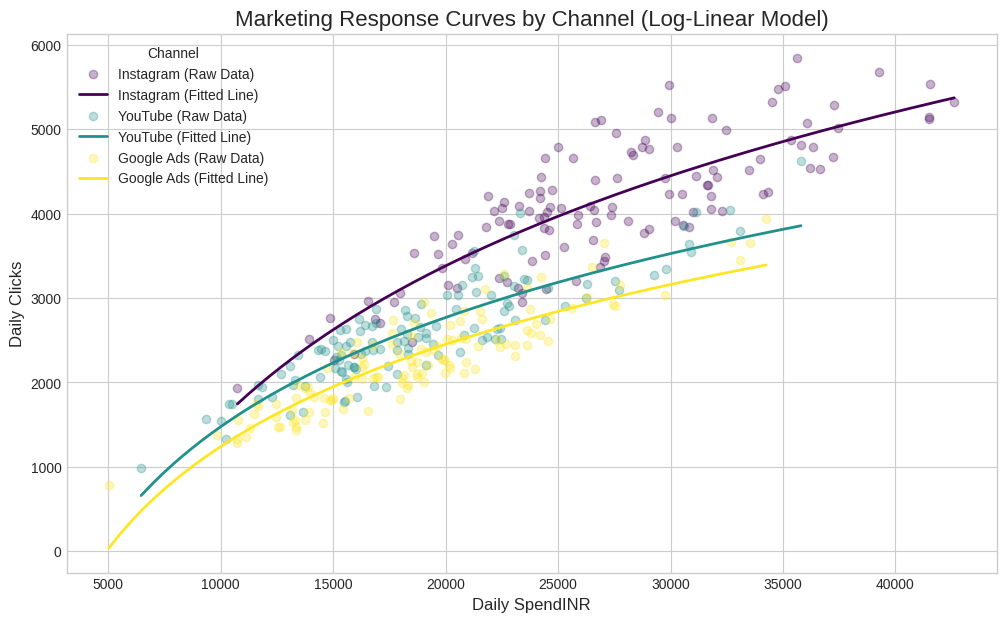

In [ ]:
# Ensure the log-transformed column exists
if 'SpendINR_log' not in df1.columns:
    df1['SpendINR_log'] = np.log(df1['SpendINR'] + 1)

# Get the unique channels for the function
channels = df1['Channel'].unique().tolist()

# Run the log-linear regression and plot the response curves
regression_models = model_and_plot_response_curves(
    data=df1,
    channels=channels,
    dep_var='Clicks',
    indep_var='SpendINR', # Use the original SpendINR for plotting x-axis
    model_type='log'
)

It appears that increasing daily spend has a strong impact on daily clicks for instagram, with youtube and google ads being relatively flatter. This means that reallocating funds slightly more to instagram is probably a good idea. Youtube and Google Ads seem to be very similarly impacted. A 64-18-18 split or a bolder/riskier 70-15-15 split might be apt.

#Question 2 - Finance Subscription

In [ ]:
df2 = dataframes['Finance_Subscription']
df2.head()

,CustomerID,City,Subscribed,TenureMonths,OrdersLast30d,AvgOrderValueINR,DeliveryFeeSavedINR
0,10001,Pune,0,0.2,3,693.83,0.00
1,10002,Bengaluru,1,9.6,8,808.05,109.36
2,10003,Mumbai,0,3.3,2,646.83,0.00
3,10004,Mumbai,1,8.1,8,778.55,129.65
4,10005,Mumbai,1,14.3,3,576.66,43.37


Again, we should first test whether the data is normally distributed.

In [ ]:
# Check normality for relevant numerical columns in df1
numerical_cols = ['TenureMonths', 'OrdersLast30d', 'AvgOrderValueINR', 'DeliveryFeeSavedINR']

for col in numerical_cols:
    print(f"Checking normality for '{col}':")
    isNormal(df2[col])
    print("-" * 30)

Checking normality for 'TenureMonths':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'OrdersLast30d':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'AvgOrderValueINR':
Data appears normally distributed
------------------------------
Checking normality for 'DeliveryFeeSavedINR':
Data does NOT appear normally distributed
------------------------------


Again, we can see that none of the data is normally disributed except AvgOrderValueINR

In [ ]:
# Check normality of the transformed columns
for col in numerical_cols:
    print(f"Checking log normality for '{col}':")
    isNormal(np.log1p(df2[col]))
    print("-" * 30)

Checking log normality for 'TenureMonths':
Data appears normally distributed
------------------------------
Checking log normality for 'OrdersLast30d':
Data does NOT appear normally distributed
------------------------------
Checking log normality for 'AvgOrderValueINR':
Data does NOT appear normally distributed
------------------------------
Checking log normality for 'DeliveryFeeSavedINR':
Data does NOT appear normally distributed
------------------------------


Applying a log transformation doesn't work either - our data is still not normal. We'll have to use the same methods as the last question.

Let's first see a summary of our data

In [ ]:
# Group by Channel and compute summaries
channel_summary = df2.groupby('City').agg(
    total_subscribed=('Subscribed', lambda x: sum(x)),
    avg_tenure=('TenureMonths', lambda x: summary(x)[0]),
    tenure_std=('TenureMonths', lambda x: summary(x)[1]),
    avg_orders=('OrdersLast30d', lambda x: summary(x)[0]),
    orders_std=('OrdersLast30d', lambda x: summary(x)[1]),
    avg_order_value=('AvgOrderValueINR', lambda x: summary(x)[0]),
    order_value_std=('AvgOrderValueINR', lambda x: summary(x)[1]),
    avg_delivery_fee=('DeliveryFeeSavedINR', lambda x: summary(x)[0]),
    delivery_fee_std=('DeliveryFeeSavedINR', lambda x: summary(x)[1])
).reset_index()

display(channel_summary)

,City,total_subscribed,avg_tenure,tenure_std,avg_orders,orders_std,avg_order_value,order_value_std,avg_delivery_fee,delivery_fee_std
0,Bengaluru,33,6.310843,5.162151,6.253012,2.966658,570.480241,111.772185,54.484940,72.949295
1,Delhi,56,8.095699,5.612484,7.569892,3.331007,589.346774,129.377521,91.388602,85.353424
2,Hyderabad,19,7.025000,4.485046,6.019231,3.196140,587.068462,119.838854,51.084808,75.599263
3,Mumbai,46,6.819820,4.929850,6.378378,2.963579,586.317027,110.240767,55.817117,74.185297
4,Pune,26,7.067213,5.973824,6.442623,3.418209,574.080656,123.657327,54.239180,71.347125


First, lets figure out whether average order value and orders differ based on subscription status for the business. For this we can use 2 sample u or t tests.

In [ ]:
#First t test - avg order value vs subscription status
avgOrderVal_vs_Subscribed = two_sample_t_test(sample1=df2[df2['Subscribed'] == 1]['AvgOrderValueINR'], sample2=df2[df2['Subscribed'] == 0]['AvgOrderValueINR'], alpha=0.05)
display(avgOrderVal_vs_Subscribed)

{'test_type': "Student's t-test (Equal Variances)",
 't_statistic': np.float64(6.739912476133637),
 'p_value': np.float64(5.580576364196648e-11),
 'reject_h0': np.True_,
 'interpretation': 'The difference between the means is statistically significant.'}

This tells us that the subscription status does affect the average order value.

In [ ]:
#Second u test - orders last 30d vs subscription status
orders_vs_Subscribed = mann_whitney_u_test(sample1=df2[df2['Subscribed'] == 1]['OrdersLast30d'], sample2=df2[df2['Subscribed'] == 0]['OrdersLast30d'])
display(orders_vs_Subscribed)

{'u_statistic': np.float64(33748.0),
 'p_value': np.float64(3.6633350189795053e-34),
 'reject_h0': np.True_,
 'interpretation': 'The distributions are statistically different.'}

Once again, we can see that the subscription status does impact the no. of orders in the last month.

Combining this we can largely say that the customers's spending behaviours depend largely on their subscription status.

Now lets see if the average order value differs across cities. We can use one way ANOVA here.

In [ ]:
avgOrders_vs_city = one_way_anova(data=df2, dependent_var='AvgOrderValueINR', factor='City', alpha=0.05)
display(avgOrders_vs_city)

{'model_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:       AvgOrderValueINR   R-squared:                       0.004
 Model:                            OLS   Adj. R-squared:                 -0.006
 Method:                 Least Squares   F-statistic:                    0.4138
 Date:                Sat, 11 Oct 2025   Prob (F-statistic):              0.799
 Time:                        10:57:47   Log-Likelihood:                -2475.2
 No. Observations:                 400   AIC:                             4960.
 Df Residuals:                     395   BIC:                             4980.
 Df Model:                           4                                         
 Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------

This tells us that the average order values don't significantly differ across cities in their mean - meaning this is more of a systemic thing that is not local.

Now let's run Kruskal Wallis for Orders30d and City, to complete our analysis of this trend.

In [ ]:
orders_vs_city = kruskal_wallis_test(data=df2, dep_var='OrdersLast30d', factor='City', alpha=0.05)
display(orders_vs_city)

{'h_statistic': np.float64(12.64564594840761),
 'p_value': np.float64(0.01314351144509513),
 'reject_h0': np.True_}

Interestingly here we can see that the number of orders placed on average differs from city to city. Since we roughly estimate a customer's spending to be no. of order x average value per order, this tells us that certain cities probably generate more revenue for us.

Now to check whether there is a linear dependence of average order values and order placed in the last 30d against the length of their tenure, let's run regression.

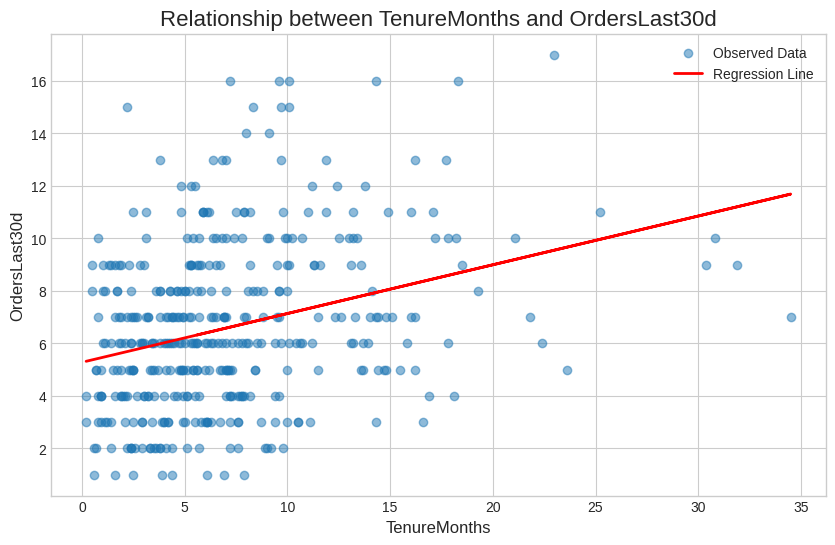

                            OLS Regression Results                            
Dep. Variable:          OrdersLast30d   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     41.42
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           3.53e-10
Time:                        10:57:47   Log-Likelihood:                -1010.9
No. Observations:                 400   AIC:                             2026.
Df Residuals:                     398   BIC:                             2034.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.2786      0.254     20.746   

In [ ]:
orders_vs_tenure = simple_linear_regression(data=df2, dep_var='OrdersLast30d', indep_var='TenureMonths')
print(orders_vs_tenure['model_summary'])

Here we can clearly see that there is little to no linear dependence of orders placed in the last 30 days and the length of a customer's tenure (as in though we have a statistically significant dependence, it is very weak - only about 9.4%).

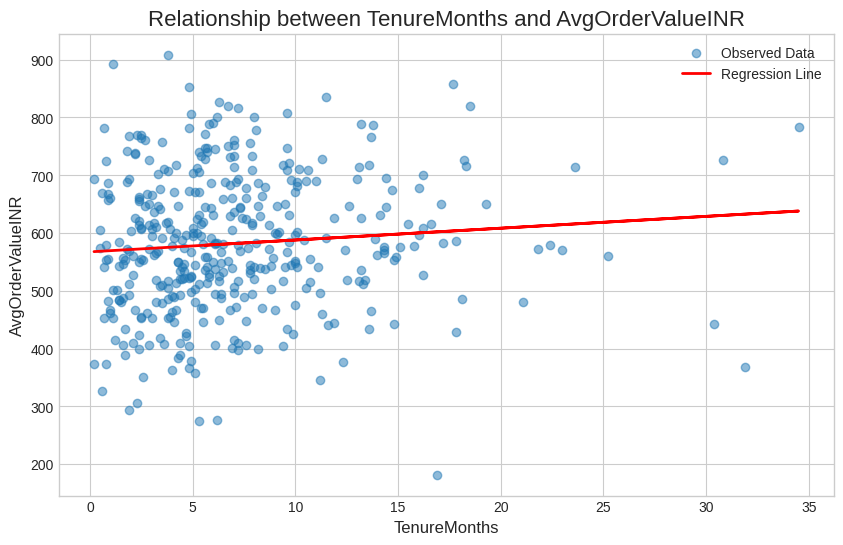

                            OLS Regression Results                            
Dep. Variable:       AvgOrderValueINR   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.341
Date:                Sat, 11 Oct 2025   Prob (F-statistic):             0.0683
Time:                        10:57:48   Log-Likelihood:                -2474.3
No. Observations:                 400   AIC:                             4953.
Df Residuals:                     398   BIC:                             4961.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          567.4852      9.874     57.473   

In [ ]:
value_vs_tenure = simple_linear_regression(data=df2, dep_var='AvgOrderValueINR', indep_var='TenureMonths')
print(value_vs_tenure['model_summary'])

Very similar results for avg order value too - statistically significant but weak dependence. About 0.8% dependence, which is tremendously low. We can therefore conclude that the length of a customer's tenure doesn't really affect our analysis much - the city and the subscription status do.

To further our analysis, lets group and summarize the data to actually quantify the results.

In [ ]:
# Group by both City and Subscription status
grouped_analysis = df2.groupby(['City', 'Subscribed']).agg(
    Avg_Orders=('OrdersLast30d', 'mean'),
    Avg_AOV=('AvgOrderValueINR', 'mean'),
    Customer_Count=('CustomerID', 'count')
).round(2)

print(grouped_analysis)

                      Avg_Orders  Avg_AOV  Customer_Count
City      Subscribed                                     
Bengaluru 0                 4.74   548.48              50
          1                 8.55   603.81              33
Delhi     0                 5.11   528.26              37
          1                 9.20   629.71              56
Hyderabad 0                 4.58   554.58              33
          1                 8.53   643.49              19
Mumbai    0                 4.95   553.86              65
          1                 8.39   632.17              46
Pune      0                 4.91   549.76              35
          1                 8.50   606.82              26


Here we can see that across every single city, subscribers place signficantly more orders than non subscribers. The uplift is substantial and consistent, with subscribers ordering roughly 70-85% more frequently (e.g., in Delhi, 9.20 orders vs. 5.11). Subscribers also consistently spend more money per order in every city. This obviously shows that the subscription program is a big success.

Now let's check whether deliveryfeesaved makes sense. We can create a SavedPerOrder metric (delivery fee saved/no. of orders). Now this metric should be largely consistent across all subscribers - representing the company's standard delivery fee.

In [ ]:
subscribers = df2[df2['Subscribed'] == 1].copy()

# Avoid division by zero if a subscriber has 0 orders
subscribers_with_orders = subscribers[subscribers['OrdersLast30d'] > 0]

subscribers_with_orders['SavedPerOrder'] = subscribers_with_orders['DeliveryFeeSavedINR'] / subscribers_with_orders['OrdersLast30d']

print("--- Analysis of 'Saved Per Order' ---")
print(subscribers_with_orders['SavedPerOrder'].describe())

--- Analysis of 'Saved Per Order' ---
count    180.000000
mean      16.079373
std        2.107956
min       12.013000
25%       14.330333
50%       16.205903
75%       17.816477
max       19.997500
Name: SavedPerOrder, dtype: float64


This result tells us - on average, each subscribed customer saves ₹16.08 per order. It also tells us that the saved per order metric differs but just about 2 rupees per order - this is a relatively low number. This tells us that the delivery fee saved data/calculation is decently reliable, consistent, and apt.

#Question 3 - Ops Delivery

In [ ]:
df3 = dataframes['Ops_Delivery']
df3.head()

,OrderID,City,Slot,DistanceKM,PromisedMins,ActualMins,OnTime
0,500001,Delhi,Off-peak,2.36,12,10.4,1
1,500002,Mumbai,Peak,2.28,10,8.3,1
2,500003,Mumbai,Off-peak,2.65,10,15.1,0
3,500004,Delhi,Off-peak,1.46,10,7.6,1
4,500005,Delhi,Off-peak,3.30,15,9.4,1


In [ ]:
# Check normality for relevant numerical columns in df3
numerical_cols_df3 = ['DistanceKM', 'PromisedMins', 'ActualMins']

print("Checking normality for numerical columns\n")
for col in numerical_cols_df3:
    print(f"Checking normality for '{col}':")
    isNormal(df3[col])
    print("-" * 30)

Checking normality for numerical columns

Checking normality for 'DistanceKM':
Data appears normally distributed
------------------------------
Checking normality for 'PromisedMins':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'ActualMins':
Data does NOT appear normally distributed
------------------------------


Even though distance here is normally distributed, the other metrics aren't.

First, lets answer: Do on-time rates differ by city? For this, we can use chi-squared test of independence

In [ ]:
on_time_results = chi_squared_test(data=df3, var1='City', var2='OnTime')
display(on_time_results['contingency_table'])
print(on_time_results['interpretation'])

OnTime,0,1
City,,
Bengaluru,164,51
Delhi,229,43
Mumbai,204,109


The relationship between 'City' and 'OnTime' is statistically significant.


So we can see that the ontime rates do infact differ city-wise. This could of course be due to a variety of reasons - traffic, weather, roads, etc.

Now let's test the dependence of time slots with the on time delivery rates to see whether peak or off peak hours make a difference.

In [ ]:
slot_vs_ontime = chi_squared_test(data=df3, var1='Slot', var2='OnTime')
display(slot_vs_ontime['contingency_table'])
print(slot_vs_ontime['interpretation'])

OnTime,0,1
Slot,,
Off-peak,229,127
Peak,368,76


The relationship between 'Slot' and 'OnTime' is statistically significant.


We get a pretty intuitive result; The time slot - off peak or peak - does in fact make a difference in the on time delivery rates. This implies that the ontime delivery rates are very largely dependent on factors like traffic. And since traffic also differs city-wise, our first analysis also follows from this.

Now lets answer - Does distance affect delivery time? But instead of just using chi-squared again, let's use regression to actually quantify a delay-distance relation.

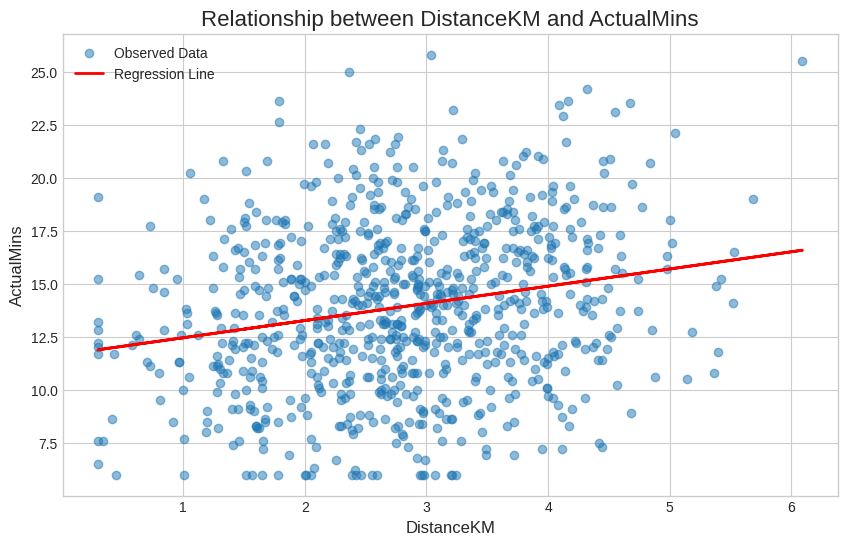

                            OLS Regression Results                            
Dep. Variable:             ActualMins   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     38.41
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           9.19e-10
Time:                        10:57:48   Log-Likelihood:                -2208.5
No. Observations:                 800   AIC:                             4421.
Df Residuals:                     798   BIC:                             4430.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6397      0.392     29.723      0.0

In [ ]:
regression_results = simple_linear_regression(data=df3, dep_var='ActualMins', indep_var='DistanceKM')
print(regression_results['model_summary'])

From this we can see that there seems to be a general trend that the Actual Mins, i.e, the delivery time, linearly increases with the Distance, however, the scatter seems to be huge, which means the dependence is relatively low. In fact, R^2 = 0.046 which means that the distance of a delivery explains only 4.6% of the variation in the time it takes, which is not very huge, however P value is 0, so we can be sure that this result is statistically significant and accurate. Also, on average, every additional kilometer adds 0.81 minutes to the delivery time.

Now lets see whether longer distance lead to more late deliveries overall. We can use logistical regression for this.

In [ ]:
features = ['DistanceKM', 'City', 'Slot']
target = 'OnTime'
logistic_results = logistic_regression_classifier(data=df3, target_var=target, feature_vars=features)
print(logistic_results['classification_report'])

              precision    recall  f1-score   support

           0       0.76      0.98      0.86       179
           1       0.67      0.10      0.17        61

    accuracy                           0.76       240
   macro avg       0.71      0.54      0.51       240
weighted avg       0.74      0.76      0.68       240



We don't need the results here - we can just tell already that the precision of this model is bad, given the features that we selected. This means that the primary drivers of late deliveries are not JUST the distance, the city, or the time slot.

So our final analysis is that the city does have a role to play in the delivery times, and the time slot at which the delivery takes place also has a significant impact individually, however this impact is not very strong. We can try obtaining more data like traffic data, parcel data, etc - which might end up giving us more insights - however, just this set of factors is not sufficient to conclude that the disparity is system-wide. Additionally, another reason for late deliveries could be addressing issues - finding a locality is often difficult because of naming and navigational conventions.

#Question 4 - Incentives Riders

In [ ]:
df4 = dataframes['Incentives_Riders']
df4.head()

,RiderID,City,Scheme,HoursWorked,DeliveriesCompleted,Cancellations,log_HoursWorked,log_DeliveriesCompleted,log_Cancellations,DeliveriesPerHour,ranks
0,9001,Pune,SchemeB,6.89,26,2,2.065596,3.295837,1.098612,3.773585,289.0
1,9002,Mumbai,SchemeC,6.97,30,1,2.075684,3.433987,0.693147,4.304161,335.0
2,9003,Bengaluru,SchemeB,5.52,23,0,1.874874,3.178054,0.000000,4.166667,327.0
3,9004,Bengaluru,SchemeC,7.82,25,1,2.177022,3.258097,0.693147,3.196931,200.0
4,9005,Bengaluru,SchemeB,7.22,29,0,2.106570,3.401197,0.000000,4.016620,317.0


In [ ]:
# Check normality for relevant numerical columns in df3
numerical_cols_df4 = ['HoursWorked', 'DeliveriesCompleted', 'Cancellations']

for col in numerical_cols_df4:
    print(f"Checking normality for '{col}':")
    isNormal(df4[col])
    print("-" * 30)

Checking normality for 'HoursWorked':
Data appears normally distributed
------------------------------
Checking normality for 'DeliveriesCompleted':
Data does NOT appear normally distributed
------------------------------
Checking normality for 'Cancellations':
Data does NOT appear normally distributed
------------------------------


HoursWorked is normally distributed, others aren't. Let's try a log transformation here

In [ ]:
for col in numerical_cols_df4:
    df4['log_'+col] = np.log1p(df4[col])
    print(f"Checking log normality for '{col}_log':")
    isNormal(df4['log_'+col])
    print("-" * 30)


Checking log normality for 'HoursWorked_log':
Data appears normally distributed
------------------------------
Checking log normality for 'DeliveriesCompleted_log':
Data does NOT appear normally distributed
------------------------------
Checking log normality for 'Cancellations_log':
Data does NOT appear normally distributed
------------------------------


Log transformation still didn't normalize the data. We'll have to use alternatives.

Firstly, we need to scheme-wise analyse rider productivity. We can use 2 different KW tests for both deliveries completed and hours worked respectively.

In [ ]:
scheme_vs_hours = kruskal_wallis_test(data=df4, dep_var='HoursWorked', factor='Scheme', alpha=0.05)
display(scheme_vs_hours)

scheme_vs_deliveries = kruskal_wallis_test(data=df4, dep_var='DeliveriesCompleted', factor='Scheme', alpha=0.05)
display(scheme_vs_deliveries)

{'h_statistic': np.float64(0.05973022996234131),
 'p_value': np.float64(0.9705764409410983),
 'reject_h0': np.False_}

{'h_statistic': np.float64(7.316974445494089),
 'p_value': np.float64(0.025771469745490553),
 'reject_h0': np.True_}

This result shows us that though the scheme didn't have a statistically significant impact on the Hours Worked, it did have a significant impact on the No. of Deliveries completed. Thus for pretty much the same number of hours put in by a Rider, the number of deliveries completed by them varies so total productivity is significantly affected. We need to quantify productivity more. We can define Deliveries per Hour for this.

In [ ]:
# Handle potential cases where HoursWorked might be zero to avoid errors
df4['DeliveriesPerHour'] = df4['DeliveriesCompleted'] / df4['HoursWorked'].replace(0, np.nan)

#Lets also check for normality of DPH
isNormal(df4['DeliveriesPerHour'])

Data does NOT appear normally distributed


False

Lets see if this metric is affected by the Scheme

In [ ]:
scheme_vs_dph = kruskal_wallis_test(data=df4, dep_var='DeliveriesPerHour', factor='Scheme', alpha=0.05)
display(scheme_vs_dph)

{'h_statistic': np.float64(7.239480720867089),
 'p_value': np.float64(0.0267896312379757),
 'reject_h0': np.True_}

This result tells us that there is a significant impact of the scheme on the Deliveries per Hour, which translates to the efficiency.

Now let's also measure whether the scheme has an impact on cancellations.

In [ ]:
scheme_vs_cancellations = kruskal_wallis_test(data=df4, dep_var='Cancellations', factor='Scheme', alpha=0.05)
display(scheme_vs_cancellations)

{'h_statistic': np.float64(38.05655322684319),
 'p_value': np.float64(5.446587269883974e-09),
 'reject_h0': np.True_}

This result shows that there is a significant impact of the scheme on cancellations.

Now to check consistency across cities, we can use SRH test with the DPH as the dependent variable, and the cities and scheme being the factors.

In [ ]:
srh_test_results = scheirer_ray_hare_test(data=df4, dep_var='DeliveriesPerHour', factor1='City', factor2='Scheme', alpha=0.05)
display(srh_test_results['anova_on_ranks'])
display(srh_test_results['significant_effects'])

,sum_sq,df,F,PR(>F),H,p_value
C(City),7.966255e+03,3.0,0.247051,0.863419,0.736254,0.864645
C(Scheme),7.481331e+04,2.0,3.480188,0.031878,6.914368,0.031518
C(City):C(Scheme),6.112954e+04,6.0,0.947881,0.460725,5.649692,0.463552
Residual,3.740463e+06,348.0,NaN,NaN,345.699686,0.524758


{'factor1': np.False_, 'factor2': np.True_, 'interaction': np.False_}

Through this result, we can deduce consistency across the cities - the city being different does not affect the efficiency in any significant way - the dependence is solely on the scheme.

Now to actually find which scheme performs the best, we can do post hoc analysis on DPH vs Scheme pairwise. We can use the U test for this

In [ ]:
groups = df4['Scheme'].unique()
pairs = list(combinations(groups, 2))
num_comparisons = len(pairs)
alpha = 0.05
pairwise_results = []

print(f"Found {len(groups)} groups. Performing {num_comparisons} pairwise comparisons...")

# Loop through each pair of schemes
for group1, group2 in pairs:
    # Prepare the data for the two groups
    data1 = df4['DeliveriesPerHour'][df4['Scheme'] == group1].dropna()
    data2 = df4['DeliveriesPerHour'][df4['Scheme'] == group2].dropna()

    # Call your original two-sample U-test function
    test_result = mann_whitney_u_test(data1, data2)

    # Store the raw results
    pairwise_results.append({
        'group1': group1,
        'group2': group2,
        'u_statistic': test_result['u_statistic'],
        'p_value_raw': test_result['p_value']
    })

# --- Apply Bonferroni correction and format the final results ---
results_df = pd.DataFrame(pairwise_results)
results_df['p_value_adj'] = results_df['p_value_raw'] * num_comparisons
results_df['p_value_adj'] = results_df['p_value_adj'].clip(upper=1.0)
results_df['reject_h0'] = results_df['p_value_adj'] < alpha

print("\n--- Final Results with Bonferroni Correction ---")
print(results_df.round(4))

Found 3 groups. Performing 3 pairwise comparisons...

--- Final Results with Bonferroni Correction ---
    group1   group2  u_statistic  p_value_raw  p_value_adj  reject_h0
0  SchemeB  SchemeC       8421.5       0.0743       0.2230      False
1  SchemeB  SchemeA       8653.0       0.0095       0.0285       True
2  SchemeC  SchemeA       7387.0       0.3524       1.0000      False


We can observe that there is a statistically significant difference between scheme a and scheme b in terms of efficiency, however, B and C remain largely similar.

In [ ]:
# Summarize 'DeliveriesPerHour' by 'Scheme'
dph_summary_by_scheme = df4.groupby('Scheme')['DeliveriesPerHour'].mean().reset_index()

print("Average DeliveriesPerHour by Scheme:")
display(dph_summary_by_scheme)

# You might also want to look at the median as the data is not normally distributed
print("\nMedian DeliveriesPerHour by Scheme:")
dph_median_by_scheme = df4.groupby('Scheme')['DeliveriesPerHour'].median().reset_index()
display(dph_median_by_scheme)

Average DeliveriesPerHour by Scheme:


,Scheme,DeliveriesPerHour
0,SchemeA,3.030738
1,SchemeB,3.283879
2,SchemeC,3.090793



Median DeliveriesPerHour by Scheme:


,Scheme,DeliveriesPerHour
0,SchemeA,3.030080
1,SchemeB,3.260870
2,SchemeC,3.147353


Looking at this, we can see that the mean and median deliveries per hour for scheme A seem to be the worst of the 3. Therefore, we should ideally rule this scheme out.

#Question 5 - Churn Customers

In [ ]:
df5 = dataframes['Churn_Customers']
df5.head()

,CustomerID,CityTier,RecencyDays,Frequency90d,Monetary90dINR,Subscribed,Complaints6m,Churned
0,700001,Tier3,0,7,5690.95,0,0.2,1
1,700002,Tier1,2,9,7729.89,0,1.2,0
2,700003,Tier1,28,12,7306.55,0,0.2,0
3,700004,Tier1,2,5,6121.55,0,0.2,0
4,700005,Tier3,8,12,5873.15,1,1.0,0


In [ ]:
#Checking for normal distribution
col_names = ['RecencyDays', 'Frequency90d', 'Monetary90dINR', 'Complaints6m']
# Check normality of the transformed columns
for col in col_names:
    print(f"Checking log normality for '{col}':")
    isNormal((df5[col]))
    print("-" * 30)

Checking log normality for 'RecencyDays':
Data does NOT appear normally distributed
------------------------------
Checking log normality for 'Frequency90d':
Data does NOT appear normally distributed
------------------------------
Checking log normality for 'Monetary90dINR':
Data appears normally distributed
------------------------------
Checking log normality for 'Complaints6m':
Data does NOT appear normally distributed
------------------------------


Again, the data is not normal - however, Monetary90dINR is.

Now first, lets identify all the variables that actually affect the Churn binary.

In [ ]:
#Chi Squared test for City Tier vs Churn
chi_squared_results_city_churn = chi_squared_test(data=df5, var1='CityTier', var2='Churned')
display(chi_squared_results_city_churn['contingency_table'])
print(chi_squared_results_city_churn['interpretation'])

Churned,0,1
CityTier,,
Tier1,377,28
Tier2,253,19
Tier3,111,12


There is no statistically significant relationship between 'CityTier' and 'Churned'.


We can see that at 95% CI, City Tier does not really affect Churn Rate meaningfully

In [ ]:
#Similarly with subscription status
chi_squared_results_city_churn = chi_squared_test(data=df5, var1='Subscribed', var2='Churned')
display(chi_squared_results_city_churn['contingency_table'])
print(chi_squared_results_city_churn['interpretation'])

Churned,0,1
Subscribed,,
0,425,40
1,316,19


There is no statistically significant relationship between 'Subscribed' and 'Churned'.


Similar results, no dependence on subscription status.

In [ ]:
# Extract 'Monetary90dINR' for churned and non-churned customers
monetary_churned = df5[df5['Churned'] == 1]['Monetary90dINR']
monetary_non_churned = df5[df5['Churned'] == 0]['Monetary90dINR']

# Perform the two-sample t-test
monetary_vs_churn = two_sample_t_test(sample1=monetary_churned, sample2=monetary_non_churned, alpha=0.05)
display(monetary_vs_churn)

{'test_type': "Student's t-test (Equal Variances)",
 't_statistic': np.float64(-2.5140323550569588),
 'p_value': np.float64(0.012131697092467125),
 'reject_h0': np.True_,
 'interpretation': 'The difference between the means is statistically significant.'}

So Monetary90dINR is a relevant factor we should take into account during our modelling

In [ ]:
#U test for Recency Days, Complaints6m, Frequency90d
recency_vs_churn = mann_whitney_u_test(sample1=df5[df5['Churned'] == 1]['RecencyDays'], sample2=df5[df5['Churned'] == 0]['RecencyDays'])
print("Recency vs Churn\n")
display(recency_vs_churn)
complaints_vs_churn = mann_whitney_u_test(sample1=df5[df5['Churned'] == 1]['Complaints6m'], sample2=df5[df5['Churned'] == 0]['Complaints6m'])
print("Complaints vs Churn\n")
display(complaints_vs_churn)
frequency_vs_churn = mann_whitney_u_test(sample1=df5[df5['Churned'] == 1]['Frequency90d'], sample2=df5[df5['Churned'] == 0]['Frequency90d'])
print("Frequency vs Churn\n")
display(frequency_vs_churn)

Recency vs Churn



{'u_statistic': np.float64(28414.0),
 'p_value': np.float64(0.000123399904859942),
 'reject_h0': np.True_,
 'interpretation': 'The distributions are statistically different.'}

Complaints vs Churn



{'u_statistic': np.float64(24380.0),
 'p_value': np.float64(0.1168691767340424),
 'reject_h0': np.False_,
 'interpretation': 'There is not enough evidence to claim a significant difference between the distributions.'}

Frequency vs Churn



{'u_statistic': np.float64(21554.5),
 'p_value': np.float64(0.8579221133998736),
 'reject_h0': np.False_,
 'interpretation': 'There is not enough evidence to claim a significant difference between the distributions.'}

This means that the only factors that are significantly relevant in our predictive modelling are Recency90d and Monetary90dINR. However, we're going to use 4 different models - Random Forest (Where we'll take all factors into account), and the rest with just the relevant factors - logistic regression, naive bayes, and CART

--- Random Forest Model Performance ---

Model Accuracy: 91.67%

Classification Report (0=Active, 1=Churned):
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       222
           1       0.00      0.00      0.00        18

    accuracy                           0.92       240
   macro avg       0.46      0.50      0.48       240
weighted avg       0.86      0.92      0.88       240


Confusion Matrix:
           Predicted Active | Predicted Churned
Actual A | 220              | 2                
Actual C | 18               | 0                


/tmp/ipython-input-4202458805.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


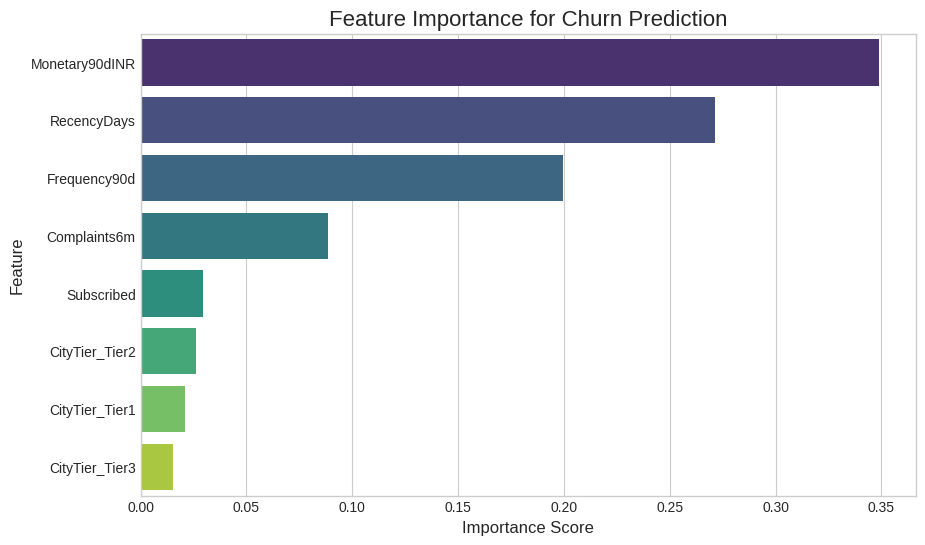

In [ ]:
    # --- 1. Define Features and Target ---
    # Using all features as requested for the Random Forest model
    features = ['CityTier', 'RecencyDays', 'Frequency90d', 'Monetary90dINR', 'Subscribed', 'Complaints6m']
    # features = ['RecencyDays', 'Frequency90d', 'Monetary90dINR']
    target = 'Churned'

    # --- 2. Preprocessing ---
    numerical_features = df5[features].select_dtypes(include=np.number).columns.tolist()
    categorical_features = df5[features].select_dtypes(exclude=np.number).columns.tolist()

    scaler = StandardScaler()
    X_numerical_scaled = scaler.fit_transform(df5[numerical_features])
    X_numerical_df = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=df5.index)

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_categorical_encoded = encoder.fit_transform(df5[categorical_features])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)
    X_categorical_df = pd.DataFrame(X_categorical_encoded, columns=encoded_feature_names, index=df5.index)

    X = pd.concat([X_numerical_df, X_categorical_df], axis=1)
    y = df5[target]

    # --- 3. Split Data ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # --- 4. Train Random Forest Model ---
    # class_weight='balanced' helps the model handle the imbalanced churn data
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    # --- 6. Evaluate Model Performance ---
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print("--- Random Forest Model Performance ---")
    print(f"\nModel Accuracy: {accuracy:.2%}")
    print("\nClassification Report (0=Active, 1=Churned):")
    print(report)
    print("\nConfusion Matrix:")
    print("           Predicted Active | Predicted Churned")
    print("Actual A | {:<16d} | {:<17d}".format(conf_matrix[0,0], conf_matrix[0,1]))
    print("Actual C | {:<16d} | {:<17d}".format(conf_matrix[1,0], conf_matrix[1,1]))

    # --- 7. Visualization: Feature Importance ---
    importances = model.feature_importances_
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title('Feature Importance for Churn Prediction', fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()

The factors that random forest marks as most important align also with our analysis - recency and monetary90d are the most significant in predicting Churn.

In [ ]:
#Logistic regression
features = ['RecencyDays', 'Monetary90dINR']
logistic_regression = logistic_regression_classifier(data=df5, target_var='Churned', feature_vars=features)
display(logistic_regression['accuracy'])
display(logistic_regression['classification_report'])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.925

'              precision    recall  f1-score   support\n\n           0       0.93      1.00      0.96       222\n           1       0.00      0.00      0.00        18\n\n    accuracy                           0.93       240\n   macro avg       0.46      0.50      0.48       240\nweighted avg       0.86      0.93      0.89       240\n'

Logistic Regression doesn't seem to be a very good model here, as even though accuracy is 93%, the recall for 1 is 0.0 which means it never correctly identifies 1, but always identifies 0. This means even though accuracy is 93% because of our data being imbalanced, the model will not be good at prediction.

In [ ]:
# --- 2. Define Features and Target ---
# We will use the original features as discretization handles non-normality
features = ['RecencyDays', 'Monetary90dINR']
target = 'Churned'

X = df5[features]
y = df5[target]

# --- 3. Preprocessing: Discretize the continuous features ---
# This bins the data (e.g., into 5 categories), which is the standard
# way to handle non-normal continuous data for Multinomial Naive Bayes.
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_binned = discretizer.fit_transform(X)

# --- 4. Split Data into Training and Testing Sets ---
# stratify=y is important for imbalanced datasets like this one
X_train, X_test, y_train, y_test = train_test_split(
  X_binned, y, test_size=0.3, random_state=42, stratify=y
)

# --- 5. Initialize and Train the Multinomial Naive Bayes Model ---
# This model is designed for discrete (binned) data
model = MultinomialNB()
model.fit(X_train, y_train)

# --- 6. Make Predictions and Evaluate the Model ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- 7. Print the Results ---
print("--- Multinomial Naive Bayes Model Performance (on Binned Data) ---")
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\nClassification Report (0=Active, 1=Churned):")
print(report)

print("\nConfusion Matrix:")
print("           Predicted Active | Predicted Churned")
print("Actual A | {:<16d} | {:<17d}".format(conf_matrix[0,0], conf_matrix[0,1]))
print("Actual C | {:<16d} | {:<17d}".format(conf_matrix[1,0], conf_matrix[1,1]))

--- Multinomial Naive Bayes Model Performance (on Binned Data) ---

Model Accuracy: 92.50%

Classification Report (0=Active, 1=Churned):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       222
           1       0.00      0.00      0.00        18

    accuracy                           0.93       240
   macro avg       0.46      0.50      0.48       240
weighted avg       0.86      0.93      0.89       240


Confusion Matrix:
           Predicted Active | Predicted Churned
Actual A | 222              | 0                
Actual C | 18               | 0                


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Very similar to logistic regression, we're facing the same issue of 'lazy learning' here - which means, even though we have 92.5% accuracy, we still fail to correctly identify any of the actual Churned values, simply because of disproportionate data. So far random forest seems like our best option.

--- CART (Decision Tree) Model Performance ---

Model Accuracy: 45.83%

Classification Report (0=Active, 1=Churned):
              precision    recall  f1-score   support

           0       0.95      0.44      0.60       222
           1       0.09      0.72      0.17        18

    accuracy                           0.46       240
   macro avg       0.52      0.58      0.38       240
weighted avg       0.89      0.46      0.57       240


Confusion Matrix:
           Predicted Active | Predicted Churned
Actual A | 97               | 125              
Actual C | 5                | 13               


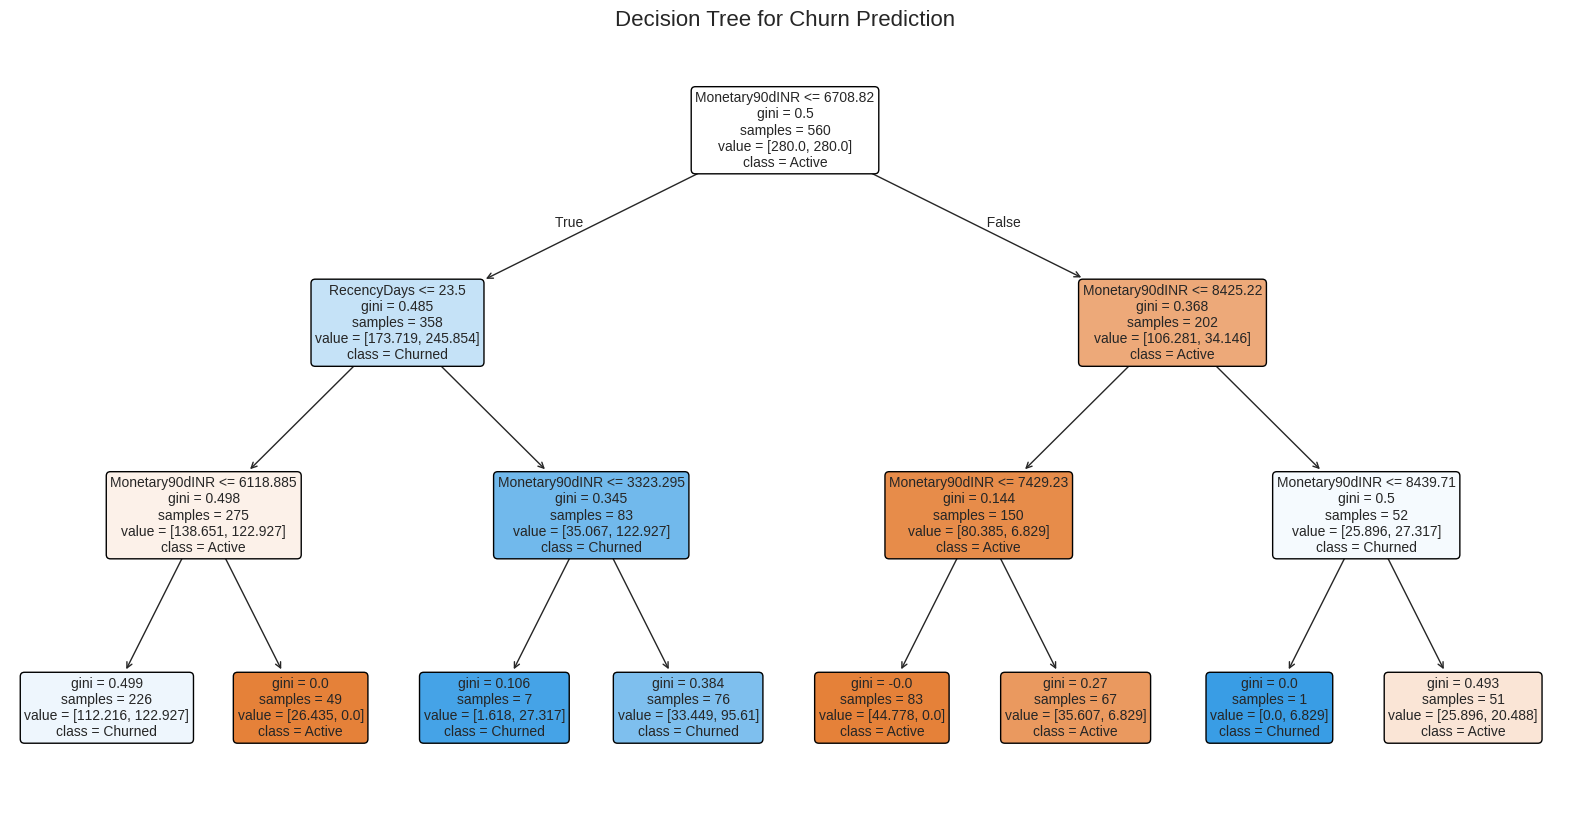

In [ ]:
#Finally lets run CART.
# --- Define Features and Target ---
# Using the two factors proven to be statistically significant
features = ['RecencyDays', 'Monetary90dINR']
target = 'Churned'

X = df5[features]
y = df5[target]

# --- Split Data into Training and Testing Sets ---
# stratify=y is crucial for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Initialize and Train the CART (Decision Tree) Model ---
# class_weight='balanced' helps the model handle the imbalanced churn data.
# max_depth is set to a low number to prevent overfitting and make the tree readable.
model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=3)
model.fit(X_train, y_train)

# --- Make Predictions and Evaluate the Model ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- Print the Performance Results ---
print("--- CART (Decision Tree) Model Performance ---")
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\nClassification Report (0=Active, 1=Churned):")
print(report)

print("\nConfusion Matrix:")
print("           Predicted Active | Predicted Churned")
print("Actual A | {:<16d} | {:<17d}".format(conf_matrix[0,0], conf_matrix[0,1]))
print("Actual C | {:<16d} | {:<17d}".format(conf_matrix[1,0], conf_matrix[1,1]))

# --- Visualize the Decision Tree ---
plt.figure(figsize=(20, 10))
plot_tree(model,
      feature_names=features,
      class_names=['Active', 'Churned'],
      filled=True,
      rounded=True,
      fontsize=10)
plt.title("Decision Tree for Churn Prediction", fontsize=16)
plt.show()

This may be much worse in terms of accuracy, but the model recall is significantly higher than logistic regression or naive bayes. We're avoiding the problem of lazy learning and overfitting, however, that comes with the tradeoff of accuracy and precision. This would come 2nd in our ranking overall.

After running 4 different predictive models, it seems that random forest is by FAR the best model, with CART coming in at second place.

NOTE: We tried running the random forest model on only the best and most important features. Though we were able to get marginal increase in accuracy by filtering out the 3 least significant factors, interestingly our accuracy was highest (92.92%) for features = ['RecencyDays', 'Frequency90d', 'Monetary90dINR']. Following this, removing frequency in fact decreased our accuracy. So theoretically, random forest with this set of features is the best model in our case - however, this could likely be vulnerable to overfitting, and might not be worth it for a marginal (<=1%) increase in accuracy.